# Coupled 2D Hydrogeophysical Modeling
**PyHydroGeophysiX · PyGIMLi · Flopy MODFLOW 6**

Test sintetico 2D accoppiato:
- **Cella 1** – Parsing dati reali → `el_pos` (48 elettrodi)
- **Cella 2** – Mesh geofisica PyGIMLi (Zona Vadosa marker=1, Substrato+Padding marker=2)
- **Cella 3** – Griglia MODFLOW 2005 con offset datum elettrodi/tensiometri
- **Cella 4** – Funzioni petrofisiche: Van Genuchten + Archie (h → θ → ρ_b)

Cross-check quote: max Dz = 0.0050 m  (soglia < 0.5 m)
OK  Quote coerenti tra i due file.

  Parametro                        Valore
  ----------------------------------------------------
  Numero elettrodi                 48
  Lunghezza profilo                56.40 m
  Spaziatura media                 1.20 m
  Quota min (Pt48)                 675.940 m a.s.l.
  Quota max (Pt1)                  686.170 m a.s.l.
  Dislivello totale                10.230 m

Prime 5  : [(0.0, 686.17), (1.2, 686.0), (2.4, 685.88), (3.6, 685.67), (4.8, 685.57)]
Ultime 5 : [(51.6, 676.86), (52.8, 676.58), (54.0, 676.31), (55.2, 676.16), (56.4, 675.94)]


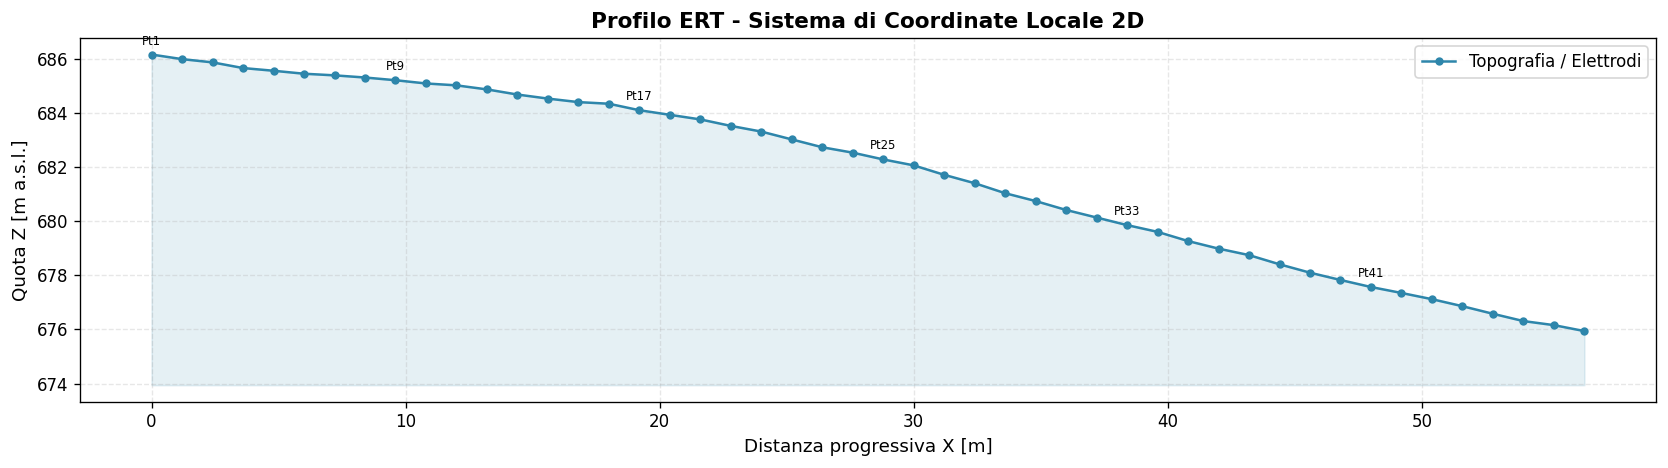


OK  el_pos costruito: 48 elettrodi - pronto per Cella 2


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 1 – Caricamento Dati e Coordinate Locali (Data Parsing)
# Input : electr_coord.csv (GPS WGS84) + 08topog_TL.txt (profilo locale X,Z)
# Output: el_pos = [(x [m], z [m a.s.l.]), ...]  – 48 elettrodi
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Directory di input ────────────────────────────────────────────────────
INPUT_DIR = Path(
    'C:/Users/luigi/git/github.com/luigimartinoisio-blip/PyHydroGeophysiX/Position'
)

# ── 1. Lettura 08topog_TL.txt ─────────────────────────────────────────────
# Formato: #,X,Y,Z,Depth  (la prima riga è l'header commentata con '#')
# X = distanza progressiva [m] in sistema locale (0–56.4 m, passo 1.2 m)
# Z = quota altimetrica assoluta [m a.s.l.]
topog = pd.read_csv(
    INPUT_DIR / '08topog_TL.txt',
    comment='#',
    header=None,
    names=['id', 'X_local', 'Y', 'Z_abs', 'Depth'],
    sep=',',
    skipinitialspace=True,
)
topog = topog.dropna(how='all').reset_index(drop=True)
topog = topog.astype({'X_local': float, 'Z_abs': float})

# ── 2. Lettura electr_coord.csv ───────────────────────────────────────────
# Formato: Nome punto, Latitudine, Longitudine, Altezza ellisoidica
# Ruolo  : verifica incrociata della quota (h ellissoidica ≈ Z topografica)
elec_gps = pd.read_csv(INPUT_DIR / 'electr_coord.csv', skipinitialspace=True)
elec_gps.columns = elec_gps.columns.str.strip()

# ── 3. Cross-check quote (soglia 0.5 m) ──────────────────────────────────
z_topog = topog['Z_abs'].values.astype(float)
z_gps   = elec_gps['Altezza ellisoidica'].values.astype(float)
delta_z = np.abs(z_topog - z_gps)
print('Cross-check quote: max Dz = {:.4f} m  (soglia < 0.5 m)'.format(delta_z.max()))
if delta_z.max() >= 0.5:
    raise ValueError('Incoerenza topografia/GPS: max Dz = {:.3f} m'.format(delta_z.max()))
print('OK  Quote coerenti tra i due file.')

# ── 4. Costruzione el_pos in coordinate locale 2D ─────────────────────────
# X = distanza progressiva dal primo elettrodo (Pt1 → X = 0)
# Z = quota altimetrica assoluta [m a.s.l.] → LIMITE SUPERIORE del dominio
x_profile = topog['X_local'].values.astype(float)
z_abs     = topog['Z_abs'].values.astype(float)

if len(x_profile) != 48:
    raise ValueError('Attesi 48 elettrodi, trovati {}'.format(len(x_profile)))

el_pos = list(zip(x_profile.tolist(), z_abs.tolist()))   # [(x1,z1), ..., (x48,z48)]

# ── 5. Riepilogo ──────────────────────────────────────────────────────────
spacing = float(np.diff(x_profile).mean())
rows = [
    ('Numero elettrodi',  str(len(el_pos))),
    ('Lunghezza profilo', '{:.2f} m'.format(x_profile[-1] - x_profile[0])),
    ('Spaziatura media',  '{:.2f} m'.format(spacing)),
    ('Quota min (Pt48)',  '{:.3f} m a.s.l.'.format(z_abs.min())),
    ('Quota max (Pt1)',   '{:.3f} m a.s.l.'.format(z_abs.max())),
    ('Dislivello totale', '{:.3f} m'.format(z_abs.max() - z_abs.min())),
]
print()
print('  {:<32} {}'.format('Parametro', 'Valore'))
print('  ' + '-' * 52)
for lbl, val in rows:
    print('  {:<32} {}'.format(lbl, val))
print()
print('Prime 5  :', el_pos[:5])
print('Ultime 5 :', el_pos[-5:])

# ── 6. Plot profilo topografico ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4), dpi=120)
xs, zs  = zip(*el_pos)
ax.plot(xs, zs, 'o-', ms=4, lw=1.5, color='#2E86AB', label='Topografia / Elettrodi')
ax.fill_between(xs, min(zs) - 2, zs, alpha=0.12, color='#2E86AB')
for i in range(0, len(xs), 8):
    ax.annotate('Pt{}'.format(i + 1), (xs[i], zs[i]),
                textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7)
ax.set_xlabel('Distanza progressiva X [m]', fontsize=11)
ax.set_ylabel('Quota Z [m a.s.l.]', fontsize=11)
ax.set_title('Profilo ERT - Sistema di Coordinate Locale 2D',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print('\nOK  el_pos costruito: {} elettrodi - pronto per Cella 2'.format(len(el_pos)))

Dominio  : X=[-15.0, 71.4] m | Z=[655.94, 686.17] m a.s.l.
Zona vadosa: X=[0.0, 56.4] m | spessore 4.0 m

Generazione mesh in corso (quality=34, smooth=True) ...

OK  Mesh generata:
   Nodi totali        : 49069
   Celle totali       : 96967

   [Zona Vadosa  marker=1  (X=0-56.4 m, 0-4 m depth)]
   Celle              : 88224
   Dim. max caratt.   : 0.1167 m  (limite ~0.10 m)
   Dim. media caratt. : 0.0702 m

   [Substrato + Padding  marker=2]
   Celle              : 8743
   Dim. max caratt.   : 2.0737 m
   Dim. media caratt. : 0.4297 m

OK  Raffinamento zona vadosa CONFORME (dim.max 0.1167 m)


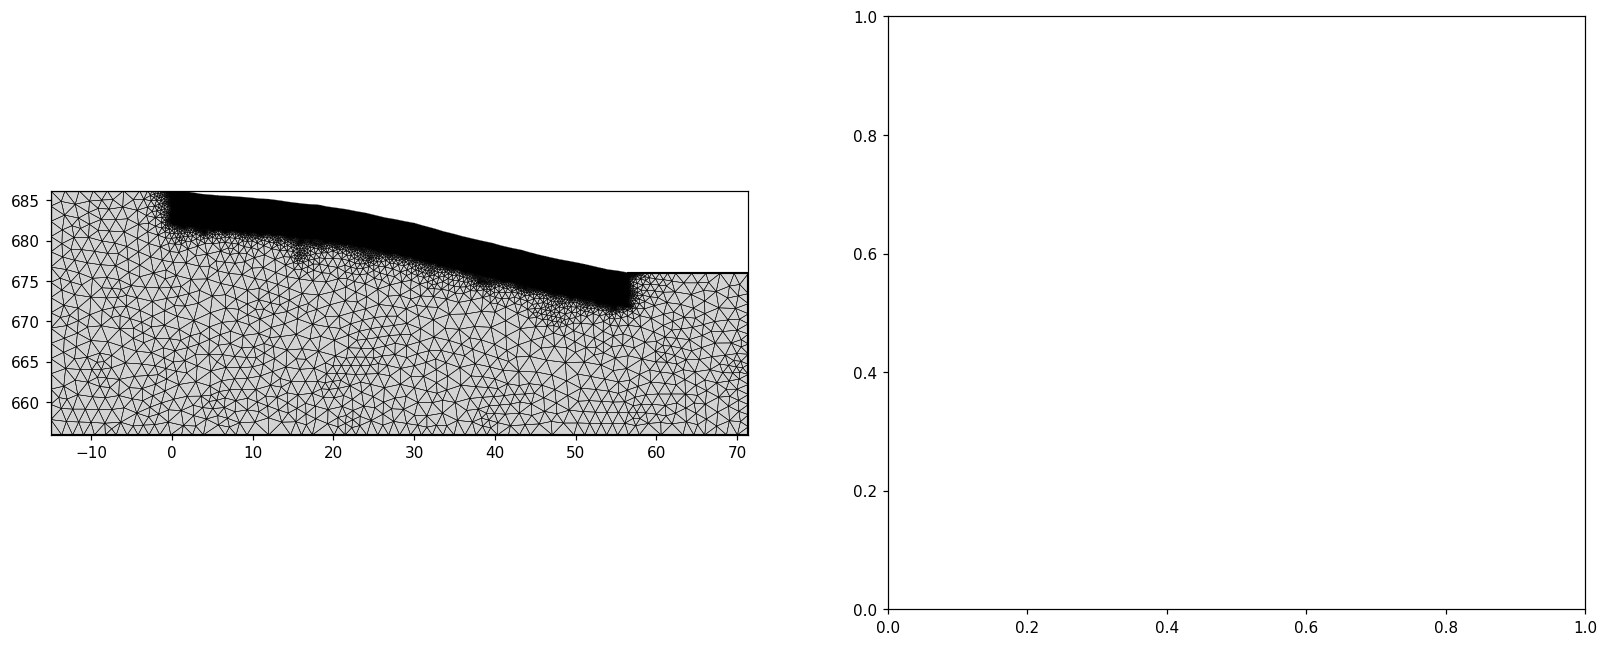

<Figure size 640x480 with 0 Axes>


OK  48 posizioni elettrodo pronte - mesh pronta per forward ERT


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 2 – Generazione della Mesh Geofisica (PyGIMLi)
#
# Architettura a due regioni:
#   marker=1  Zona Vadosa  (X=0-56.4 m, profondita' 0-4 m)  area<=0.005 m^2
#   marker=2  Substrato + Padding laterale                    area<=2.0   m^2
#
# Triangle crea smooth grading automatico tra le due regioni.
# quality=34 evita triangoli distorti nella zona di transizione.
# =══════════════════════════════════════════════════════════════════════════
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import matplotlib.pyplot as plt

# ── Parametri geometrici ──────────────────────────────────────────────────
x_arr = np.array([p[0] for p in el_pos])
z_arr = np.array([p[1] for p in el_pos])

LATERAL_EXT    = 15.0   # [m] padding laterale oltre il profilo
DEPTH_TOTAL    = 20.0   # [m] profondita' max sotto z_min degli elettrodi
VADOSA_DEPTH   =  4.0   # [m] spessore zona vadosa idrogeologicamente attiva
# Area max vadosa: sqrt(2 * 0.005) = 0.10 m → dim. caratteristica <= 0.10 m
VADOSA_AREA    = 0.005  # [m^2]
SUBSTRATE_AREA = 2.0    # [m^2] substrato + padding (computazionalmente leggero)

z_min_surf = z_arr.min()
z_max_surf = z_arr.max()
z_bottom   = z_min_surf - DEPTH_TOTAL
x_min      = x_arr[0]  - LATERAL_EXT
x_max      = x_arr[-1] + LATERAL_EXT

print('Dominio  : X=[{:.1f}, {:.1f}] m | Z=[{:.2f}, {:.2f}] m a.s.l.'.format(
    x_min, x_max, z_bottom, z_max_surf))
print('Zona vadosa: X=[{:.1f}, {:.1f}] m | spessore {:.1f} m'.format(
    x_arr[0], x_arr[-1], VADOSA_DEPTH))

# ── 1. PLC Mondo intero (marker=2 – substrato + padding laterale) ─────────
# Confine superiore: topografia + padding piatto
# Confine inferiore: piano orizzontale a z_bottom
boundary_pts = (
    [[x_min, float(z_arr[0])]] +
    [[float(x), float(z)] for x, z in zip(x_arr, z_arr)] +
    [[x_max, float(z_arr[-1])],
     [x_max, z_bottom],
     [x_min, z_bottom]]
)
world_plc = mt.createPolygon(
    boundary_pts, isClosed=True, marker=2, area=SUBSTRATE_AREA
)

# ── 2. PLC Zona Vadosa (marker=1 – X=0..56.4 m, depth 0..4 m) ────────────
# Top: topografia esatta degli elettrodi (senza padding laterale)
# Base: topografia - VADOSA_DEPTH (parallela punta per punta alla topografia)
# Lati: segmenti verticali in X=x_arr[0] e X=x_arr[-1]
vadosa_top = [[float(x), float(z)] for x, z in zip(x_arr, z_arr)]
vadosa_bot = [[float(x), float(z) - VADOSA_DEPTH]
              for x, z in zip(x_arr[::-1], z_arr[::-1])]
vadosa_plc = mt.createPolygon(
    vadosa_top + vadosa_bot, isClosed=True, marker=1, area=VADOSA_AREA
)

# ── 3. Fusione PLCs e aggiunta nodi elettrodo ─────────────────────────────
full_plc = mt.mergePLC([world_plc, vadosa_plc])

# Elettrodi come nodi espliciti di superficie + sub-surface anchor
for xi, zi in el_pos:
    full_plc.createNode([float(xi), float(zi)])
    full_plc.createNode([float(xi), float(zi) - 0.01])   # stabilita' FEM

# Nodi ausiliari alla base della zona vadosa ogni 3 elettrodi:
# guidano il smooth grading dalla regione densa a quella sparsa
for xi, zi in list(zip(x_arr, z_arr))[::3]:
    full_plc.createNode([float(xi), float(zi) - VADOSA_DEPTH])

# ── 4. Generazione mesh ───────────────────────────────────────────────────
# quality=34 → angolo minimo piu' stringente per ridurre triangoli distorti
# nella zona di transizione tra le due regioni (smooth grading automatico)
print('\nGenerazione mesh in corso (quality=34, smooth=True) ...')
mesh = mt.createMesh(full_plc, quality=34, smooth=True)

# ── 5. Statistiche per regione (marker) ──────────────────────────────────
cell_areas   = np.array([c.size() for c in mesh.cells()])
cell_markers = np.array([c.marker() for c in mesh.cells()])
char_len     = np.sqrt(2.0 * cell_areas)

vadosa_mask = cell_markers == 1
substr_mask = cell_markers == 2
cl_vadosa   = char_len[vadosa_mask]
cl_substr   = char_len[substr_mask]

print('\nOK  Mesh generata:')
print('   Nodi totali        : {}'.format(mesh.nodeCount()))
print('   Celle totali       : {}'.format(mesh.cellCount()))
print()
print('   [Zona Vadosa  marker=1  (X=0-56.4 m, 0-{:.0f} m depth)]'.format(VADOSA_DEPTH))
print('   Celle              : {}'.format(vadosa_mask.sum()))
print('   Dim. max caratt.   : {:.4f} m  (limite ~0.10 m)'.format(cl_vadosa.max()))
print('   Dim. media caratt. : {:.4f} m'.format(cl_vadosa.mean()))
print()
print('   [Substrato + Padding  marker=2]')
print('   Celle              : {}'.format(substr_mask.sum()))
print('   Dim. max caratt.   : {:.4f} m'.format(cl_substr.max()))
print('   Dim. media caratt. : {:.4f} m'.format(cl_substr.mean()))

if cl_vadosa.max() <= 0.12:
    print('\nOK  Raffinamento zona vadosa CONFORME (dim.max {:.4f} m)'.format(cl_vadosa.max()))
else:
    print('\nATT Raffinamento FUORI LIMITE ({:.4f} m) - ridurre VADOSA_AREA'.format(
        cl_vadosa.max()))

# ── 6. Visualizzazione (Aggiornata con controllo assoluto dei colori) ─────
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

markers_arr = np.array([c.marker() for c in mesh.cells()], dtype=float)

# Creazione colormap discreta: Marker 1 -> Skyblue, Marker 2 -> Lightgray
region_cmap = ListedColormap(['skyblue', 'lightgray'])

# Creazione proxy per la legenda
patch_vad = mpatches.Patch(color='skyblue', label='Vadose Zone')
patch_sub = mpatches.Patch(color='lightgray', label='Substrate & Padding')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=110)

# — Full view: cells colored by region marker —
pg.show(mesh, data=markers_arr, ax=axes[0], showMesh=True,
        cMap=region_cmap, colorBar=False)
axes[0].plot(x_arr, z_arr, 'rv', ms=5, zorder=10, label='Electrodes')
axes[0].plot(x_arr, z_arr - VADOSA_DEPTH, 'b--', lw=1.5,
             label=f'Vadose Base (-{VADOSA_DEPTH:.0f} m)')
axes[0].set_title('Geophysical Mesh - Full View', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Z [m a.s.l.]')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles + [patch_vad, patch_sub], loc='lower left', fontsize=9)

# — Zoom on vadose zone (electrodes 12-24) —
j0, j1 = 11, 24
pg.show(mesh, data=markers_arr, ax=axes[1], showMesh=True,
        cMap=region_cmap, colorBar=False)
axes[1].plot(x_arr, z_arr, 'rv', ms=5, zorder=10, label='Electrodes')
axes[1].plot(x_arr, z_arr - VADOSA_DEPTH, 'b--', lw=1.5,
             label=f'Vadose Base (-{VADOSA_DEPTH:.0f} m)')
axes[1].set_xlim(x_arr[j0] - 0.5, x_arr[j1] + 0.5)
axes[1].set_ylim(z_arr[j0:j1+1].min() - VADOSA_DEPTH - 0.5,
                 z_arr[j0:j1+1].max() + 0.3)
axes[1].set_title(
    f'Vadose Zone Zoom (0-{VADOSA_DEPTH:.0f} m depth)\nMax Cell Size = {cl_vadosa.max():.3f} m | Cells = {vadosa_mask.sum()}',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('X [m]')
axes[1].set_ylabel('Z [m a.s.l.]')

handles_z, labels_z = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles_z + [patch_vad], loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

sensor_arr = np.array([[float(x), float(z)] for x, z in el_pos])
print('\nOK  {} posizioni elettrodo pronte - mesh pronta per forward ERT'.format(len(el_pos)))

Griglia 2D: NLAY=5, NROW=1, NCOL=47
delr = 1.20 m (uniforme)
top_elev : min=676.050 m  max=686.085 m  range=10.035 m

Verifica centri cella (valori medi su 47 colonne):
  Centro L2 a 0.2000 m sotto top_elev  → 0.3000 m sotto TGS (target -0.30 m)
  Centro L4 a 0.7000 m sotto top_elev  → 0.8000 m sotto TGS (target -0.80 m)

OK  Pacchetto DIS creato:
   NLAY=5, NROW=1, NCOL=47
   Extent X: [0.00, 56.40] m
   Extent Z: [672.050, 686.085] m a.s.l.

  REPORT SENSORI TENSIOMETRICI – POSIZIONI E QUOTE NODALI
  (Layer 2 ≈ -30 cm TGS  |  Layer 4 ≈ -80 cm TGS)
  X target  col_idx   X cella [m]       Z nodo L2 [m asl]     Z nodo L4 [m asl]     
  ----------------------------------------------------------------------
  8.0       6         7.8000            685.1600              684.6600              
  31.0      25        30.6000           681.6950              681.1950              
  51.0      42        51.0000           676.7900              676.2900              

Nota: Z nodo = quota assoluta 

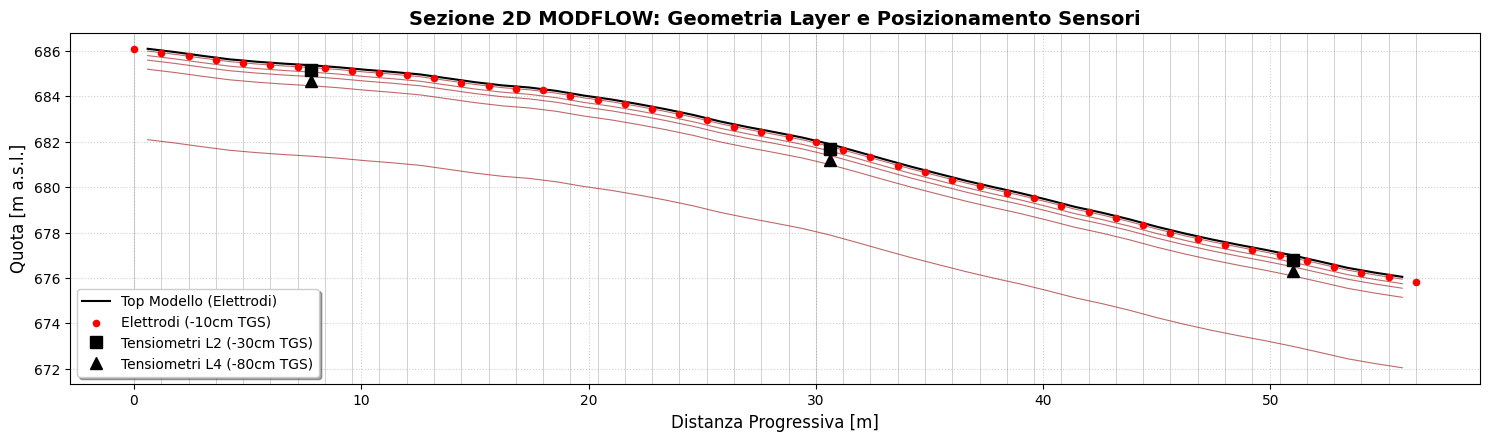

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 3 – Griglia MODFLOW 2D (flopy.modflow.ModflowDis)
#            con Z-offset chirurgico e localizzazione sensori tensiometrici
# ═══════════════════════════════════════════════════════════════════════════
#
# GEOMETRIA CELLE:
# ───────────────────────────────────────────────────────────────────────────
# Gli elettrodi (48) sono i BORDI delle colonne.
# ncol = 48 - 1 = 47 celle. Il centro X della cella j è la media di X[j] e X[j+1].
# Il top della cella j è la media delle quote Z degli elettrodi ai suoi bordi.
#
# Z-OFFSET CHIRURGICO (5 layer):
# ───────────────────────────────────────────────────────────────────────────
# Vero Piano Campagna (TGS)           z_TGS
# Elettrodi (piantati -10 cm dal TGS) z_el = z_TGS - 0.10
# TOP modello MODFLOW                 top_elev = z_el  (le 47 medie)
#
# Basi layer (offset dal top_elev di ogni cella):
#   L1 base: top_elev - 0.1   → centro L1 a -0.05 m dal top
#   L2 base: top_elev - 0.3   → centro L2 a -0.20 m dal top
#                                  → -0.20 + (-0.10) = -0.30 m dal TGS  ✓ Tens.1
#   L3 base: top_elev - 0.5   → centro L3 a -0.40 m dal top
#   L4 base: top_elev - 0.9   → centro L4 a -0.70 m dal top
#                                  → -0.70 + (-0.10) = -0.80 m dal TGS  ✓ Tens.2
#   L5 base: top_elev - 4.0   → copre l'intera zona vadosa attiva
# ───────────────────────────────────────────────────────────────────────────
import numpy as np
import flopy
import matplotlib.pyplot as plt
from pathlib import Path

# ── 1. Arrays da Cella 1 ─────────────────────────────────────────────────
x_arr = np.array([p[0] for p in el_pos])   # 48 posizioni X degli elettrodi [m]
z_arr = np.array([p[1] for p in el_pos])   # 48 quote Z degli elettrodi [m a.s.l.]

assert len(x_arr) == 48, 'Attesi 48 elettrodi, trovati {}'.format(len(x_arr))

# ── 2. Griglia orizzontale: ncol = 47 celle (elettrodi = bordi) ───────────
NCOL = len(x_arr) - 1                               # 47
NROW = 1                                            # 2D pseudo-profilo
NLAY = 5                                            # 5 layer chirurgici

delr = np.full(NCOL, 1.2)                           # larghezza cella = 1.2 m uniforme
delc = np.array([1.0])                              # larghezza riga (pseudo-2D)

# Centri X delle celle (per localizzazione sensori)
x_col_center = (x_arr[:-1] + x_arr[1:]) / 2.0     # shape (47,)

# ── 3. Topografia celle: media delle quote Z agli elettrodi bordo ─────────
top_elev = (z_arr[:-1] + z_arr[1:]) / 2.0          # shape (47,)  [m a.s.l.]

print('Griglia 2D: NLAY={}, NROW={}, NCOL={}'.format(NLAY, NROW, NCOL))
print('delr = {:.2f} m (uniforme)'.format(delr[0]))
print('top_elev : min={:.3f} m  max={:.3f} m  range={:.3f} m'.format(
    top_elev.min(), top_elev.max(), top_elev.max() - top_elev.min()))

# ── 4. Basi layer (Z-offset chirurgico) ──────────────────────────────────
# Tutti gli offset sono RELATIVI a top_elev di ogni cella (topografia variabile)
# Shape botm: (NLAY, NROW, NCOL) = (5, 1, 47)
OFFSETS = np.array([0.1, 0.3, 0.5, 0.9, 4.0])   # profondita' basi layer [m]

botm = np.zeros((NLAY, NROW, NCOL))
for k, dz in enumerate(OFFSETS):
    botm[k, 0, :] = top_elev - dz                  # quota assoluta base layer k

# Top array per MODFLOW DIS (shape NROW x NCOL)
top_2d = top_elev.reshape(NROW, NCOL)

# ── 5. Verifica centri cella (quote assolute) ─────────────────────────────
# Centro L1: (top_elev + base_L1) / 2 = top_elev - 0.05  → -0.05 m dal top
# Centro L2: (base_L1 + base_L2) / 2 = top_elev - 0.20  → -0.20 m dal top = -0.30 m TGS
# Centro L4: (base_L3 + base_L4) / 2 = top_elev - 0.70  → -0.70 m dal top = -0.80 m TGS
ctr_abs = np.zeros((NLAY, NCOL))
for k in range(NLAY):
    top_k = top_elev if k == 0 else botm[k-1, 0, :]
    bot_k = botm[k, 0, :]
    ctr_abs[k, :] = (top_k + bot_k) / 2.0

# Offset dal top_elev (dovrebbe essere costante columnwise per verifica)
ctr_offset = top_elev - ctr_abs[1, :]   # Layer 2: atteso ~0.20 m
ctr_offset_L4 = top_elev - ctr_abs[3, :]  # Layer 4: atteso ~0.70 m
print('\nVerifica centri cella (valori medi su 47 colonne):')
print('  Centro L2 a {:.4f} m sotto top_elev  → {:.4f} m sotto TGS (target -0.30 m)'.format(
    ctr_offset.mean(), ctr_offset.mean() + 0.10))
print('  Centro L4 a {:.4f} m sotto top_elev  → {:.4f} m sotto TGS (target -0.80 m)'.format(
    ctr_offset_L4.mean(), ctr_offset_L4.mean() + 0.10))

# ── 6. Costruzione modello flopy.modflow (MODFLOW 2005) ───────────────────
MODEL_WS = Path(
    'C:/Users/luigi/git/github.com/luigimartinoisio-blip/PyHydroGeophysiX/mf2005_coupled'
)
MODEL_WS.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'coupled_hydrogeo_dis'

model = flopy.modflow.Modflow(
    modelname = MODEL_NAME,
    exe_name  = 'mf2005',        # deve essere nel PATH; non eseguito qui
    model_ws  = str(MODEL_WS),
    version   = 'mf2005',
)

# DIS – discretizzazione spazio-temporale
dis = flopy.modflow.ModflowDis(
    model,
    nlay = NLAY,
    nrow = NROW,
    ncol = NCOL,
    delr = delr,
    delc = delc,
    top  = top_2d,
    botm = botm,
    nper = 1,
    perlen   = [1.0],
    nstp     = [1],
    steady   = [True],
    itmuni   = 4,    # unità tempo: giorni
    lenuni   = 2,    # unità lunghezza: metri
)

print('\nOK  Pacchetto DIS creato:')
print('   NLAY={}, NROW={}, NCOL={}'.format(dis.nlay, dis.nrow, dis.ncol))
print('   Extent X: [{:.2f}, {:.2f}] m'.format(
    float(x_col_center[0]) - 0.6, float(x_col_center[-1]) + 0.6))
print('   Extent Z: [{:.3f}, {:.3f}] m a.s.l.'.format(
    float(botm[-1, 0, :].min()), float(top_elev.max())))

# ── 7. Centri cella (quote assolute) per Layer 2 e Layer 4 ───────────────
# ModflowDis non espone zcellcenters; usiamo ctr_abs calcolato al passo 5.
# ctr_abs[k, j] = (top_k[j] + bot_k[j]) / 2  →  shape (NLAY, NCOL)

# Layer 2 → indice 1;  Layer 4 → indice 3
z_L2 = ctr_abs[1, :]   # shape (47,)   [m a.s.l.]
z_L4 = ctr_abs[3, :]   # shape (47,)   [m a.s.l.]

# ── 8. Localizzazione sensori a X = 8 m, 31 m, 51 m ──────────────────────
SENS_X_TARGETS = [8.0, 31.0, 51.0]   # [m] posizioni nominali sensori

print('\n' + '=' * 72)
print('  REPORT SENSORI TENSIOMETRICI – POSIZIONI E QUOTE NODALI')
print('  (Layer 2 ≈ -30 cm TGS  |  Layer 4 ≈ -80 cm TGS)')
print('=' * 72)
print('  {:<10}{:<10}{:<18}{:<22}{:<22}'.format(
    'X target', 'col_idx', 'X cella [m]', 'Z nodo L2 [m asl]', 'Z nodo L4 [m asl]'))
print('  ' + '-' * 70)

for x_target in SENS_X_TARGETS:
    # Indice di colonna più vicino al target
    col_idx = int(np.argmin(np.abs(x_col_center - x_target)))
    x_real  = float(x_col_center[col_idx])
    z_sens2 = float(z_L2[col_idx])
    z_sens4 = float(z_L4[col_idx])
    print('  {:<10.1f}{:<10d}{:<18.4f}{:<22.4f}{:<22.4f}'.format(
        x_target, col_idx, x_real, z_sens2, z_sens4))

print('=' * 72)
print()
print('Nota: Z nodo = quota assoluta centro-cella [m a.s.l.].')
print('      L2 centro a -0.20 m dal top modello = -0.30 m dal TGS.')
print('      L4 centro a -0.70 m dal top modello = -0.80 m dal TGS.')
print()
print('OK  Cella 3 completata. Modello MODFLOW 2005 pronto (non eseguito).')
print('    Workspace: {}'.format(MODEL_WS))

# ── 9. Visualizzazione Grafica della Griglia e dei Sensori ────────────────
fig, ax = plt.subplots(figsize=(15, 7))

# Plot dei bordi delle celle (Griglia MODFLOW)
for j in range(NCOL + 1):
    ax.axvline(x_arr[j], color='gray', lw=0.5, alpha=0.5)
for k in range(NLAY):
    ax.plot(x_col_center, botm[k, 0, :], color='brown', lw=0.8, alpha=0.7)
ax.plot(x_col_center, top_elev, color='black', lw=1.5, label='Top Modello (Elettrodi)')

# Plot Elettrodi (punti sulla superficie del modello)
ax.scatter(x_arr, z_arr - 0.10, color='red', s=20, label='Elettrodi (-10cm TGS)', zorder=5)

# Plot Sensori Tensiometrici (posizioni reali calcolate)
for i, x_target in enumerate(SENS_X_TARGETS):
    col_idx = int(np.argmin(np.abs(x_col_center - x_target)))
    ax.plot(x_col_center[col_idx], z_L2[col_idx], 'ks', markersize=8, 
            label='Tensiometri L2 (-30cm TGS)' if i==0 else "")
    ax.plot(x_col_center[col_idx], z_L4[col_idx], 'k^', markersize=8, 
            label='Tensiometri L4 (-80cm TGS)' if i==0 else "")

ax.set_title("Sezione 2D MODFLOW: Geometria Layer e Posizionamento Sensori", fontsize=14, fontweight='bold')
ax.set_xlabel("Distanza Progressiva [m]", fontsize=12)
ax.set_ylabel("Quota [m a.s.l.]", fontsize=12)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='lower left', frameon=True, shadow=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

--- FASE 5: FORZANTE IDROLOGICA (Modo: REAL) ---

Scrittura dei file di input per MODFLOW-NWT...
Avvio della simulazione...

✓ OK - Simulazione terminata con successo (175 Stress Periods).


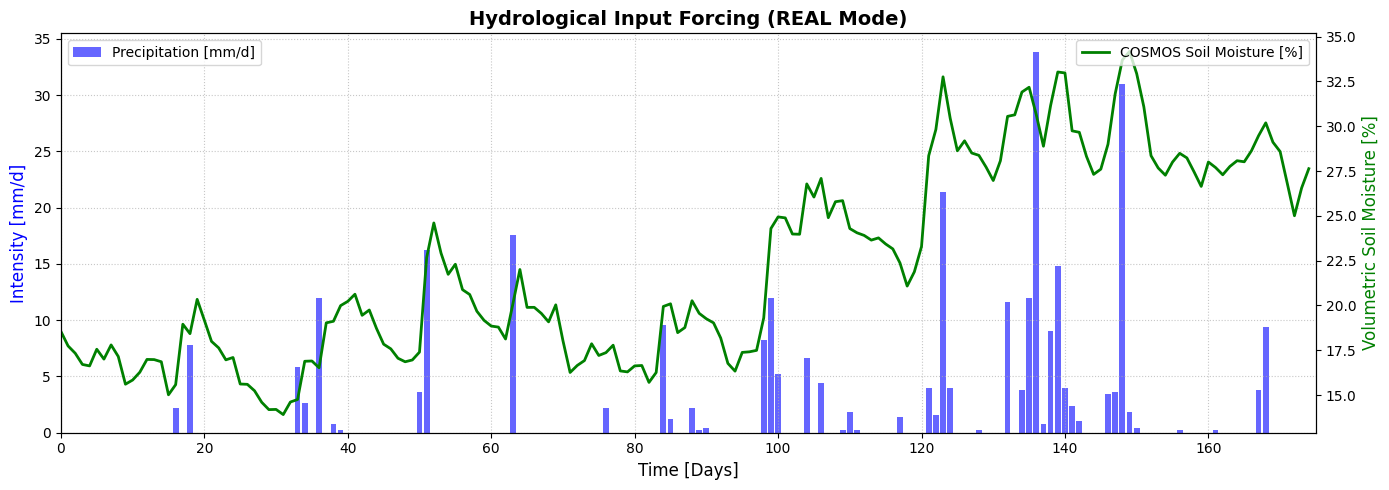

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 4 – Il Motore Idrologico Transitorio (MODFLOW-NWT)
# Obiettivo: Switch tra Pioggia Sintetica a gradino e Dati Reali COSMOS
# ═══════════════════════════════════════════════════════════════════════════
import flopy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 0. L'INTERRUTTORE STRATEGICO ──────────────────────────────────────────
FORCING_MODE = 'REAL'  # Scegli 'SYNTHETIC' o 'REAL'

print(f"--- FASE 5: FORZANTE IDROLOGICA (Modo: {FORCING_MODE}) ---")

workspace = os.path.join(os.getcwd(), 'mf2005_coupled')
if not os.path.exists(workspace):
    os.makedirs(workspace)

# Usiamo la versione NWT, imbattibile per la zona non confinata
mf = flopy.modflow.Modflow("hydro_transient", version="mfnwt", exe_name="mfnwt", model_ws=workspace)

# Recupero Geometria (da Cella 3)
nlay = 5; nrow = 1; ncol = len(x_arr) - 1
delr = 1.2; delc = 1.0

top_elev = (z_arr[:-1] + z_arr[1:]) / 2
top_elev = top_elev.reshape((nrow, ncol))

botm = np.zeros((nlay, nrow, ncol))
botm[0, 0, :] = top_elev - 0.1
botm[1, 0, :] = top_elev - 0.3
botm[2, 0, :] = top_elev - 0.5
botm[3, 0, :] = top_elev - 0.9
botm[4, 0, :] = top_elev - 4.0

# ── 1. DEFINIZIONE INPUT IDROLOGICO (Temporale & Ricarica) ────────────────
if FORCING_MODE == 'SYNTHETIC':
    # La tua logica originale a gradino
    nper = 3
    perlen = [1.0, 5.0, 10.0]
    nstp = [1, 5, 10]
    steady = [True, False, False]
    
    rech_data = {0: 0.0, 1: 0.05, 2: 0.0} # m/d
    
    # Preparazione dati per il plot
    plot_days = [0, 1, 6, 16]
    plot_rech = [0, 50, 50, 0] # mm/d

elif FORCING_MODE == 'REAL':
    # Lettura dati COSMOS
    df = pd.read_csv('COSMOS-Carlone.xlsx.csv')
    precip_mm = df['Cumulated precipitation [mm]'].values
    sm_obs = df['COSMOS Daily mean Volumetric SM'].values
    
    nper = len(precip_mm)  # 175 giorni
    perlen = np.ones(nper)
    nstp = np.ones(nper, dtype=int)
    steady = np.zeros(nper, dtype=bool)
    steady[0] = True # Il primo giorno stabilizza il modello
    
    # Dizionario Ricarica per NWT (conversione da mm a m/d)
    rech_data = {i: precip_mm[i] / 1000.0 for i in range(nper)}

else:
    raise ValueError("FORCING_MODE deve essere 'SYNTHETIC' o 'REAL'")

# Pacchetti DIS e RCH
dis = flopy.modflow.ModflowDis(mf, nlay=nlay, nrow=nrow, ncol=ncol, nper=nper,
                               delr=delr, delc=delc, top=top_elev, botm=botm,
                               perlen=perlen, nstp=nstp, steady=steady)
rch = flopy.modflow.ModflowRch(mf, rech=rech_data)

# ── 2. FISICA E CONDIZIONI AL CONTORNO (BAS, UPW, CHD, NWT) ───────────────
ibound = np.ones((nlay, nrow, ncol), dtype=int)
strt = top_elev - 1.0  # La falda parte 1m sotto il terreno
bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=strt)

# UPW: Fondamentale per zone non confinate (Sostituisce LPF)
hk = 0.5; vka = 0.05; sy = 0.15; ss = 1e-5
upw = flopy.modflow.ModflowUpw(mf, laytyp=1, hk=hk, vka=vka, sy=sy, ss=ss)

# CHD: Condizioni al bordo dinamiche applicate a TUTTI i periodi
head_up = float(top_elev[0, 0] - 3.5)
head_down = float(top_elev[0, ncol-1] - 3.5)
chd_data = {}
for i in range(nper):
    chd_data[i] = [
        [4, 0, 0, head_up, head_up],
        [4, 0, ncol-1, head_down, head_down]
    ]
chd = flopy.modflow.ModflowChd(mf, stress_period_data=chd_data)

# Solver NWT (Newton)
nwt = flopy.modflow.ModflowNwt(mf, headtol=1e-3, fluxtol=1e-3, maxiterout=500)

# Output Control
spd = {}
for kper in range(nper):
    for kstp in range(nstp[kper]):
        spd[(kper, kstp)] = ['save head', 'save budget']
oc = flopy.modflow.ModflowOc(mf, stress_period_data=spd)

# ── 3. ESECUZIONE ────────────────────────────────────────────────────────
print("\nScrittura dei file di input per MODFLOW-NWT...")
mf.write_input()

print("Avvio della simulazione...")
success, buff = mf.run_model(silent=True)

if success:
    print(f"\n✓ OK - Simulazione terminata con successo ({nper} Stress Periods).")
else:
    print("\n❌ ERRORE - MODFLOW non è riuscito a convergere.")

# ── 4. VISUALIZZAZIONE INPUT IDROLOGICO ──────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

if FORCING_MODE == 'SYNTHETIC':
    ax1.step(plot_days, plot_rech, where='post', color='blue', lw=2.5, label='Recharge [mm/d]')
    ax1.fill_between(plot_days, plot_rech, step="post", alpha=0.15, color='blue')
    ax1.set_xlim(0, 16)
    
elif FORCING_MODE == 'REAL':
    ax1.bar(range(nper), precip_mm, color='blue', alpha=0.6, label='Precipitation [mm/d]')
    ax2 = ax1.twinx()
    ax2.plot(range(nper), sm_obs, color='green', lw=2, label='COSMOS Soil Moisture [%]')
    ax2.set_ylabel('Volumetric Soil Moisture [%]', color='green', fontsize=12)
    ax2.legend(loc='upper right')
    ax1.set_xlim(0, nper)

ax1.set_xlabel("Time [Days]", fontsize=12)
ax1.set_ylabel("Intensity [mm/d]", color='blue', fontsize=12)
ax1.set_title(f"Hydrological Input Forcing ({FORCING_MODE} Mode)", fontsize=14, fontweight='bold')
ax1.grid(True, ls=':', alpha=0.7)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 5 - Il Ponte Petrofisico (Versione Batch Multi-Temporale)
# Obiettivo: Calcolare la resistività per 2 (Sintetico) o 7 (Reale) frame
# ═══════════════════════════════════════════════════════════════════════════
import os
import numpy as np
import flopy.utils.binaryfile as bf

# ── 0. CONFIGURAZIONE PERCORSI E CARICAMENTO DATI MODFLOW ──────────────────
model_ws = 'mf2005_coupled' 
modelname = 'hydro_transient'
path_hds = os.path.join(model_ws, modelname + '.hds')

print(f"--- FASE 0: ACCESSO AI DATI IDROLOGICI ---")

if 'FORCING_MODE' not in locals():
    raise NameError("CRITICO: FORCING_MODE non definito. Esegui prima la Cella 4.")

# Assegnazione dinamica della LISTA di target temporali
if FORCING_MODE == 'SYNTHETIC':
    TARGET_DAYS = [6.0, 16.0] 
elif FORCING_MODE == 'REAL':
    TARGET_DAYS = [29.0, 70.0, 93.0, 113.0, 134.0, 144.0, 156.0] 
else:
    raise ValueError("FORCING_MODE non riconosciuto.")

# Conservo DAY_DRY e DAY_WET per compatibilità
DAY_DRY = TARGET_DAYS[0]
DAY_WET = TARGET_DAYS[-1]

if os.path.exists(path_hds):
    headobj = bf.HeadFile(path_hds)
    heads_dict = {}
    try:
        # Estrazione massiva: raccogliamo tutti i frame e riduciamo da 3D a 2D
        for day in TARGET_DAYS:
            heads_dict[day] = headobj.get_data(totim=day)[:, 0, :]
        print(f"-> Modalità Forzante: {FORCING_MODE}")
        print(f"-> Estratti carichi idraulici per i giorni: {TARGET_DAYS}")
    except Exception as e:
        print(f"ERRORE di estrazione: {e}")
        print(f"Tempi disponibili nel file: {headobj.get_times()}")
        raise
else:
    raise FileNotFoundError(f"ERRORE: Il file {path_hds} non esiste. Riesegui la Cella 4.")

# ── 1. FIX GEOMETRICO: CALCOLO Z_CENTERS PER SOTTRAZIONE CARICO ────────────
# Questo fix assicura che Z_centers esista PRIMA di calcolare la suzione
nlay_local = heads_dict[TARGET_DAYS[0]].shape[0]
ncol_local = heads_dict[TARGET_DAYS[0]].shape[1]
Z_centers = np.zeros((nlay_local, ncol_local))

# Calcolo quote centri cella (Elevazioni s.l.m.)
Z_centers[0, :] = (top_elev[0, :] + botm[0, 0, :]) / 2.0
for i in range(1, nlay_local):
    Z_centers[i, :] = (botm[i-1, 0, :] + botm[i, 0, :]) / 2.0
print(f"-> Geometria ricostruita correttamente per {nlay_local} layers.")

# ── 2. L'INTERRUTTORE STRATEGICO ──────────────────────────────────────────
PETRO_MODE = 'LAB' 

print(f"\n--- FASE 1: INIZIALIZZAZIONE PETROFISICA (Modo: {PETRO_MODE}) ---")

def vg_theta(h, theta_s, theta_r, alpha, n):
    h_suction = np.where(h < 0, np.abs(h), 0)
    m = 1.0 - (1.0 / n)
    return theta_r + (theta_s - theta_r) / (1.0 + (alpha * h_suction)**n)**m

def archie_rho(theta, a, m, rho_w):
    return a * rho_w * (theta)**(-m)

def hyprop_resistivity(h, alpha, n, m, n_a, rho_sat):
    suction = np.where(h < 0, np.abs(h), 0.0)
    ec_norm = (1.0 + (alpha * suction)**n)**(-m * n_a)
    return rho_sat / ec_norm

# ── 3. ESECUZIONE CONDIZIONALE MULTI-FRAME (CON SOTTRAZIONE QUOTE) ────────
rho_true_dict = {}

if PETRO_MODE == 'LITERATURE':
    p_vg = {'theta_s': 0.45, 'theta_r': 0.20, 'alpha': 1.5, 'n': 1.5}
    p_archie = {'a': 1.0, 'm': 2.0, 'rho_w': 15.0}
    for day, h_abs in heads_dict.items():
        # SOTTRAZIONE CRUCIALE: Carico - Quota = Pressione (Suzione)
        h_suction = h_abs - Z_centers 
        theta_current = vg_theta(h_suction, **p_vg)
        rho_true_dict[day] = archie_rho(theta_current, **p_archie)

elif PETRO_MODE == 'LAB':
    p_surf = {'alpha': 0.504, 'n': 1.239, 'm': 0.193, 'n_a': 3.460, 'rho_sat': 9.27}
    p_deep = {'alpha': 0.619, 'n': 1.236, 'm': 0.191, 'n_a': 5.068, 'rho_sat': 10.77}
    for day, h_abs in heads_dict.items():
        # SOTTRAZIONE CRUCIALE: Carico - Quota = Pressione (Suzione)
        h_suction = h_abs - Z_centers
        rho_current = np.zeros_like(h_suction)
        rho_current[0:2, :] = hyprop_resistivity(h_suction[0:2, :], **p_surf)
        rho_current[2:, :] = hyprop_resistivity(h_suction[2:, :], **p_deep)
        rho_true_dict[day] = rho_current

# Aggiornamento variabili per retro-compatibilità Cella 6 e 7
rho_dry = rho_true_dict[DAY_DRY]
rho_wet = rho_true_dict[DAY_WET]

print(f"✓ Resistività calcolata correttamente usando la suzione reale.")
print(f"-> Calcolo completato per {len(TARGET_DAYS)} frame.")

--- FASE 0: ACCESSO AI DATI IDROLOGICI ---
-> Modalità Forzante: REAL
-> Estratti carichi idraulici per i giorni: [29.0, 70.0, 93.0, 113.0, 134.0, 144.0, 156.0]
-> Geometria ricostruita correttamente per 5 layers.

--- FASE 1: INIZIALIZZAZIONE PETROFISICA (Modo: LAB) ---
✓ Resistività calcolata correttamente usando la suzione reale.
-> Calcolo completato per 7 frame.


--- GENERAZIONE GRIGLIA VISIVA GROUND TRUTH ---


C:\Users\luigi\AppData\Local\Temp\ipykernel_3672\503975045.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


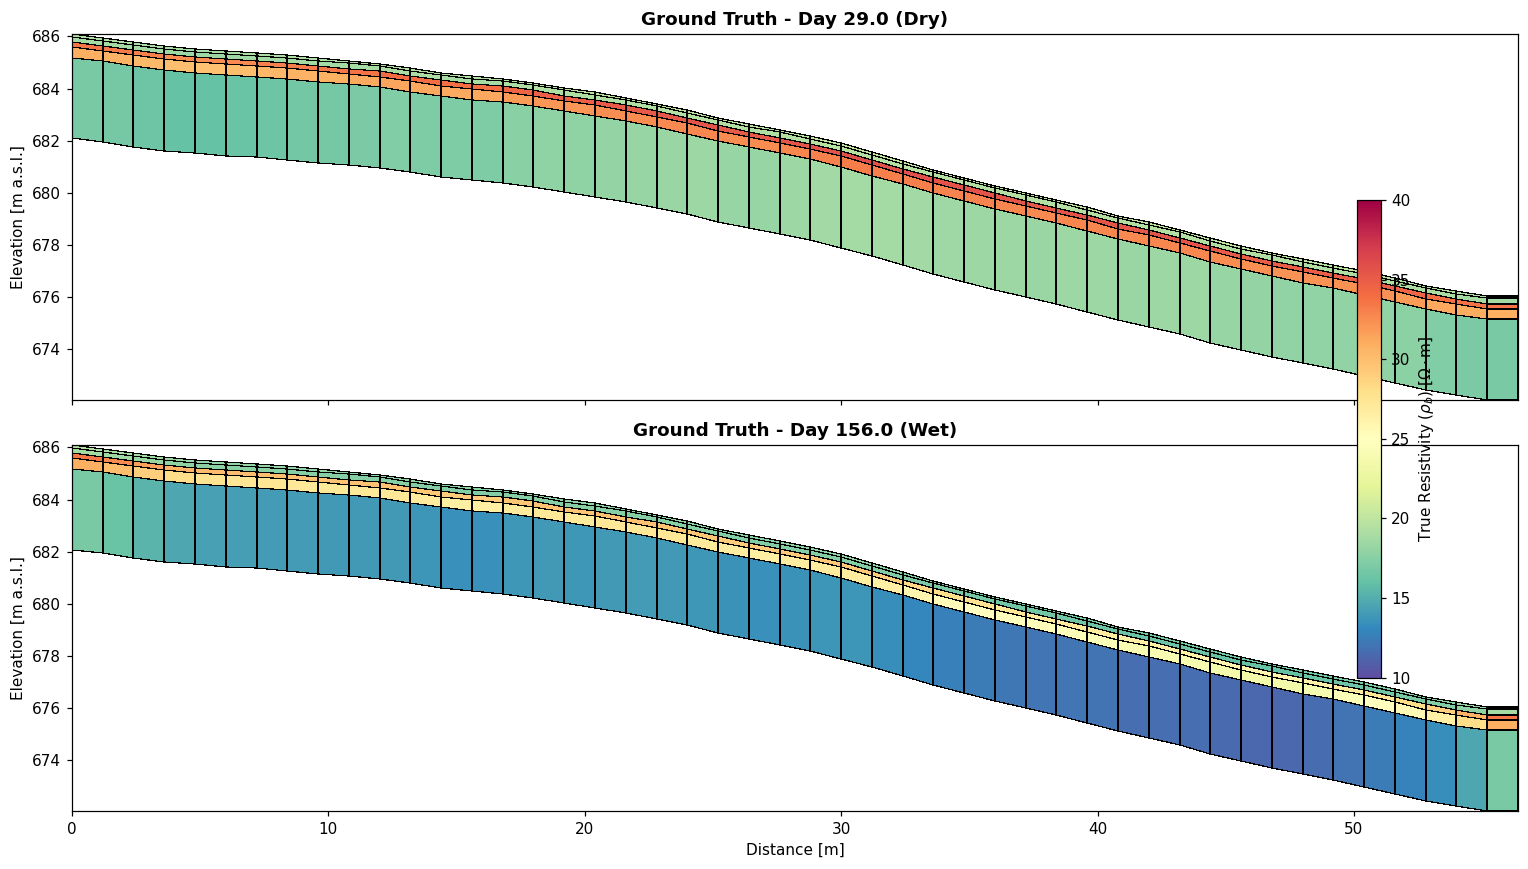


--- VERIFICA SENSORI (Ground Truth) ---
Colonna 6 (X = 7.2m):
  Layer 2 (-30cm) -> Day 29.0: 18.60 ohm-m | Day 156.0: 17.53 ohm-m
  Layer 4 (-80cm) -> Day 29.0: 30.40 ohm-m | Day 156.0: 27.42 ohm-m
Colonna 25 (X = 30.0m):
  Layer 2 (-30cm) -> Day 29.0: 19.57 ohm-m | Day 156.0: 17.33 ohm-m
  Layer 4 (-80cm) -> Day 29.0: 33.21 ohm-m | Day 156.0: 26.86 ohm-m
Colonna 42 (X = 50.4m):
  Layer 2 (-30cm) -> Day 29.0: 19.23 ohm-m | Day 156.0: 16.64 ohm-m
  Layer 4 (-80cm) -> Day 29.0: 32.21 ohm-m | Day 156.0: 25.01 ohm-m


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 6 – Visualizzazione Ground Truth 2D
# Obiettivo: Mostrare la vera resistività già calcolata dalla Cella 5
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

print("--- GENERAZIONE GRIGLIA VISIVA GROUND TRUTH ---")

# Controllo di sicurezza: se queste variabili mancano, hai saltato la Cella 5
if 'rho_wet' not in locals() or 'rho_dry' not in locals():
    raise NameError("CRITICO: Matrici di resistività mancanti. Esegui la Cella 5 (Ponte Petrofisico).")

# ── 1. Costruzione della Griglia Visiva 2D (MODFLOW -> Matplotlib) ────────
X_edges = np.zeros((nlay + 1, ncol + 1))
Z_edges = np.zeros((nlay + 1, ncol + 1))

for i in range(nlay + 1):
    X_edges[i, :] = x_arr

Z_edges[0, :-1] = top_elev[0, :]
Z_edges[0, -1] = top_elev[0, -1]
for i in range(nlay):
    Z_edges[i+1, :-1] = botm[i, 0, :]
    Z_edges[i+1, -1] = botm[i, 0, -1]

# ── 2. Visualizzazione ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), dpi=110, sharex=True, sharey=True)

cmap = 'Spectral_r' 
norm = colors.Normalize(vmin=10, vmax=40) 

# ORDINAMENTO CRONOLOGICO AUTOMATICO
if DAY_WET < DAY_DRY:
    data_top, day_top, label_top = rho_wet, DAY_WET, "Wet"
    data_bot, day_bot, label_bot = rho_dry, DAY_DRY, "Dry"
else:
    data_top, day_top, label_top = rho_dry, DAY_DRY, "Dry"
    data_bot, day_bot, label_bot = rho_wet, DAY_WET, "Wet"

# Plot Superiore
mesh1 = axes[0].pcolormesh(X_edges, Z_edges, data_top, shading='flat', cmap=cmap, norm=norm, edgecolors='k', linewidth=0.1)
axes[0].set_title(f'Ground Truth - Day {day_top} ({label_top})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Elevation [m a.s.l.]')

# Plot Inferiore
mesh2 = axes[1].pcolormesh(X_edges, Z_edges, data_bot, shading='flat', cmap=cmap, norm=norm, edgecolors='k', linewidth=0.1)
axes[1].set_title(f'Ground Truth - Day {day_bot} ({label_bot})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Distance [m]')
axes[1].set_ylabel('Elevation [m a.s.l.]')

# Etichetta rigorosa in inglese
cbar = fig.colorbar(mesh2, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r'True Resistivity ($\rho_b$) [$\Omega\cdot$m]')

plt.tight_layout()
plt.show()

# ── 3. Diagnostica Puntuale ───────────────────────────────────────────────
print("\n--- VERIFICA SENSORI (Ground Truth) ---")
col_idxs = [6, 25, 42]
for c in col_idxs:
    # Estraiamo i valori rispettando l'ordine cronologico top/bot
    val_top_30 = data_top[1, c]
    val_bot_30 = data_bot[1, c]
    val_top_80 = data_top[3, c]
    val_bot_80 = data_bot[3, c]
    
    print(f"Colonna {c} (X = {x_arr[c]:.1f}m):")
    print(f"  Layer 2 (-30cm) -> Day {day_top}: {val_top_30:.2f} ohm-m | Day {day_bot}: {val_bot_30:.2f} ohm-m")
    print(f"  Layer 4 (-80cm) -> Day {day_top}: {val_top_80:.2f} ohm-m | Day {day_bot}: {val_bot_80:.2f} ohm-m")

<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
C:\Users\luigi\AppData\Local\Temp\ipykernel_3672\3838176882.py:52: SyntaxWarning: invalid escape sequence '\s'
  df_seq = pd.read_csv(file_path, skiprows=50, sep='\s+', names=['idx', 'A', 'B', 'M', 'N'])


--- FASE 7: ACQUISIZIONE GEOFISICA VIRTUALE ---
1. Mapping dell'idrologia sulla mesh geofisica per 7 frame...
-> Variazione REALE trasferita sulla mesh: 9.2518 Ohm.m
2. Caricamento sequenza reale e posizionamento elettrodi...
-> Sequenza caricata: 1224 misure valide.
3. Simulazione Forward Modeling (Rumore 1%) per 7 frame...
   -> Calcolo frame Giorno 29.0...


27/04/26 - 14:39:23 - pyGIMLi - INFO - Calculate geometric factors.
27/04/26 - 14:41:13 - pyGIMLi - INFO - Data error estimate (min:max)  0.010003467976661441 : 0.010096046526238418


   -> Calcolo frame Giorno 70.0...


27/04/26 - 14:42:49 - pyGIMLi - INFO - Data error estimate (min:max)  0.010003660175387528 : 0.010101702985648175
27/04/26 - 14:44:26 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000360741451923 : 0.01010068168358297


...

   -> Calcolo frame Giorno 144.0...


27/04/26 - 14:49:47 - pyGIMLi - INFO - Data error estimate (min:max)  0.010004208169215894 : 0.010125850634603712


   -> Calcolo frame Giorno 156.0...


27/04/26 - 14:51:37 - pyGIMLi - INFO - Data error estimate (min:max)  0.010004117992134973 : 0.010128800042490664



4. Generazione Pseudo-Sezioni (Visualizzazione Estremi)...


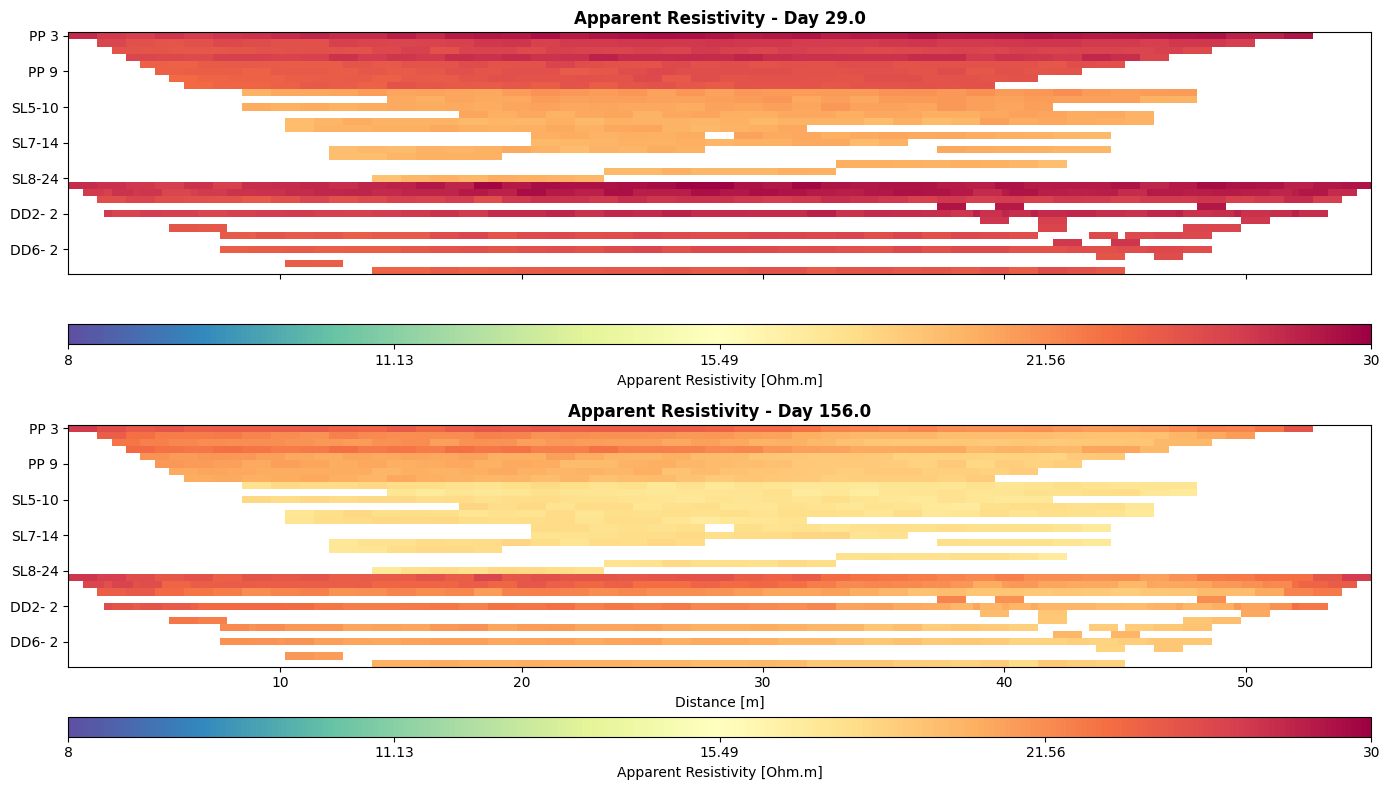

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 7 – Forward Modeling (Versione Indipendente e Blindata)
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.physics.ert as ert
import pandas as pd
from scipy.interpolate import griddata

print("--- FASE 7: ACQUISIZIONE GEOFISICA VIRTUALE ---")

if 'rho_true_dict' not in locals():
    raise NameError("CRITICO: rho_true_dict non trovato. Esegui la Nuova Cella 5.")

# ── 1. RICOSTRUZIONE E MAPPING (Versione Corretta) ──────────────────────────
X_centers = np.zeros((nlay, ncol))
Z_centers = np.zeros((nlay, ncol))

for i in range(nlay):
    X_centers[i, :] = x_arr[:-1] + (delr / 2.0)

# Calcolo centri cella verticali (Z) - Assicuriamoci che siano coerenti con la Cella 5
Z_centers[0, :] = (top_elev[0, :] + botm[0, 0, :]) / 2.0
for i in range(1, nlay):
    Z_centers[i, :] = (botm[i-1, 0, :] + botm[i, 0, :]) / 2.0

xf_flat = X_centers.flatten()
zf_flat = Z_centers.flatten()
points = np.vstack((xf_flat, zf_flat)).T

cx = np.array([c.center().x() for c in mesh.cells()])
cz = np.array([c.center().y() for c in mesh.cells()])

print(f"1. Mapping dell'idrologia sulla mesh geofisica per {len(TARGET_DAYS)} frame...")
mesh_rho_dict = {}
for day, rho_matrix in rho_true_dict.items():
    # USIAMO 'linear' per sentire i gradienti di umidità tra i layer
    mesh_rho_dict[day] = griddata(points, rho_matrix.flatten(), (cx, cz), method='linear', fill_value=np.median(rho_matrix))

# CHECK DI SOPRAVVIVENZA DEL SEGNALE
diff_check = np.max(np.abs(mesh_rho_dict[TARGET_DAYS[-1]] - mesh_rho_dict[TARGET_DAYS[0]]))
print(f"-> Variazione REALE trasferita sulla mesh: {diff_check:.4f} Ohm.m")

# ── 2. CARICAMENTO SEQUENZA E SENSORI ─────────────────────────────────────
print("2. Caricamento sequenza reale e posizionamento elettrodi...")
sensors = np.zeros((len(x_arr), 2))
sensors[:, 0] = x_arr
sensors[:, 1] = z_arr 

file_path = '2DDsup+MG+DDsup_rec.txt'
df_seq = pd.read_csv(file_path, skiprows=50, sep='\s+', names=['idx', 'A', 'B', 'M', 'N'])
df_seq = df_seq.apply(pd.to_numeric, errors='coerce').dropna()

scheme = pg.DataContainerERT()
for s in sensors:
    scheme.createSensor(s)

for i, row in df_seq.iterrows():
    A, B = int(row['A']) - 1, int(row['B']) - 1
    M, N = int(row['M']) - 1, int(row['N']) - 1
    scheme.createFourPointData(scheme.size(), A, B, M, N)

print(f"-> Sequenza caricata: {scheme.size()} misure valide.")

# ── 3. SIMULAZIONE (RUMORE 1% PER AVVALORARE IL SEGNALE DEBOLE) ───────────
# Ho abbassato il rumore come stabilito: 3% era troppo distruttivo
print(f"3. Simulazione Forward Modeling (Rumore 1%) per {len(TARGET_DAYS)} frame...")
data_dict = {}
for day, mesh_rho in mesh_rho_dict.items():
    print(f"   -> Calcolo frame Giorno {day}...")
    data = ert.simulate(mesh, scheme=scheme, res=mesh_rho, noiseLevel=0.01, noiseAbs=1e-5, seed=42)
    data_dict[day] = data

# ── 4. VISUALIZZAZIONE ────────────────────────────────────────────────────
print("\n4. Generazione Pseudo-Sezioni (Visualizzazione Estremi)...")
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
cMin, cMax = 8, 30 

day_first = TARGET_DAYS[0]
day_last = TARGET_DAYS[-1]

ert.show(data_dict[day_first], ax=axs[0], cMin=cMin, cMax=cMax, cmap='Spectral', label='Apparent Resistivity [Ohm.m]')
axs[0].set_title(f"Apparent Resistivity - Day {day_first}", fontsize=12, fontweight='bold')

ert.show(data_dict[day_last], ax=axs[1], cMin=cMin, cMax=cMax, cmap='Spectral', label='Apparent Resistivity [Ohm.m]')
axs[1].set_title(f"Apparent Resistivity - Day {day_last}", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Distance [m]")

# Retro-compatibilità
data_dry, data_wet = data_dict[day_first], data_dict[day_last]

plt.tight_layout()
plt.show()

27/04/26 - 14:54:14 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:14 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:14 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:14 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:14 - pyGIMLi - INFO - Creating forward mesh from region infos.
27/04/26 - 14:54:15 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
27/04/26 - 14:54:15 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
27/04/26 - 14:54:15 - pyGIMLi - INFO - Use median(data values)=25.233949423979475


--- FASE 8: INVERSIONE TOMOGRAFICA A CASCATA ---
1. Purificazione e Inversione Sequenziale per 7 frame...
   -> Giorno 29.0 (BASELINE): Dati validi 1224. Inversione libera in corso...


27/04/26 - 14:54:20 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:20 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:20 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:20 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
27/04/26 - 14:54:20 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
27/04/26 - 14:54:20 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
27/04/26 - 14:54:20 - pyGIMLi - INFO - Use median(data values)=23.659013576385917




   -> Giorno 70.0: Dati validi 1224 | Variazione dati dal frame 29.0: 1740.73 Ohm.m


27/04/26 - 14:54:25 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:25 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:25 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:25 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:25 - pyGIMLi - INFO - Creating forward mesh from region infos.
27/04/26 - 14:54:25 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
27/04/26 - 14:54:25 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
27/04/26 - 14:54:25 - pyGIMLi - INFO - Use median(data values)=24.00635258042558


...



   -> Giorno 144.0: Dati validi 1224 | Variazione dati dal frame 134.0: 2746.94 Ohm.m


27/04/26 - 14:54:45 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:45 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:45 - pyGIMLi - INFO - Found 2 regions.
27/04/26 - 14:54:45 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
27/04/26 - 14:54:45 - pyGIMLi - INFO - Creating forward mesh from region infos.
27/04/26 - 14:54:45 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
27/04/26 - 14:54:45 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1982 Cells: 3708 Boundaries: 2908
27/04/26 - 14:54:45 - pyGIMLi - INFO - Use median(data values)=20.151385589137732




   -> Giorno 156.0: Dati validi 1224 | Variazione dati dal frame 144.0: 335.13 Ohm.m


27/04/26 - 14:54:50 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
27/04/26 - 14:54:50 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 





✓ Tutte le inversioni a cascata completate con successo.

2. Generazione Tomografie (Visualizzazione Estremi Cronologici)...


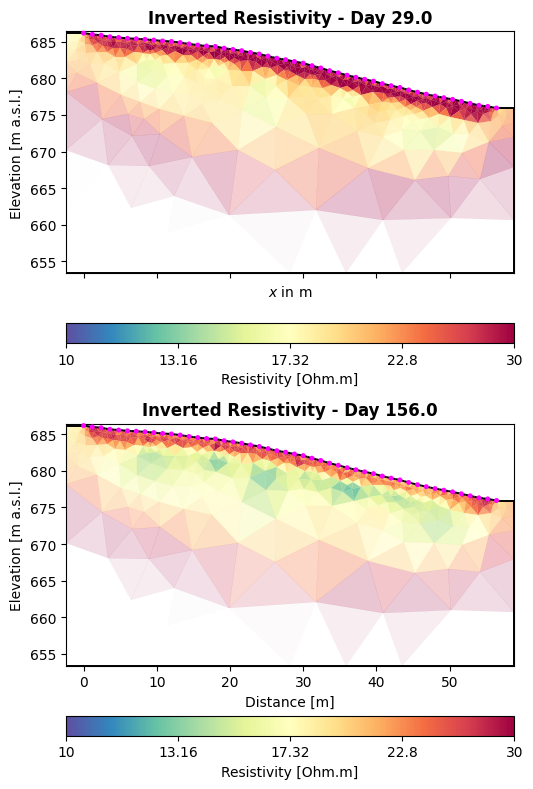


--- VERIFICA SENSORI DOPO INVERSIONE (Estremi Cronologici) ---
Sensori a X = 8.0 m:
  -30 cm -> Day 29.0: 26.6 Ohm.m | Day 156.0: 24.4 Ohm.m
  -80 cm -> Day 29.0: 27.6 Ohm.m | Day 156.0: 25.0 Ohm.m
Sensori a X = 31.0 m:
  -30 cm -> Day 29.0: 29.4 Ohm.m | Day 156.0: 24.7 Ohm.m
  -80 cm -> Day 29.0: 29.3 Ohm.m | Day 156.0: 23.9 Ohm.m
Sensori a X = 51.0 m:
  -30 cm -> Day 29.0: 28.9 Ohm.m | Day 156.0: 23.4 Ohm.m
  -80 cm -> Day 29.0: 28.8 Ohm.m | Day 156.0: 22.7 Ohm.m


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 8 – L'Inversione Geofisica BATCH A CASCATA (Sequential Time-Lapse)
# Obiettivo: Ricostruire i modelli vincolando le variazioni al giorno precedente
# ═══════════════════════════════════════════════════════════════════════════
import pygimli as pg
import matplotlib.pyplot as plt
import numpy as np
import pygimli.physics.ert as ert

print("--- FASE 8: INVERSIONE TOMOGRAFICA A CASCATA ---")

if 'data_dict' not in locals():
    raise NameError("CRITICO: data_dict non trovato. Esegui la Cella 7.")

mgr_dict = {}
inv_dict = {}
starting_model = None  # Variabile chiave per il vincolo a cascata

print(f"1. Purificazione e Inversione Sequenziale per {len(TARGET_DAYS)} frame...")

# Il ciclo itera su TARGET_DAYS (2 giorni per SYNTHETIC, 7 per REAL)
for i, day in enumerate(TARGET_DAYS):
    data = data_dict[day]
    
    # Purificazione dai valori negativi
    data.remove(data['rhoa'] <= 0)
    
    # Diagnostica: i dati apparenti stanno cambiando rispetto a ieri?
    if i > 0:
        prev_day = TARGET_DAYS[i-1]
        prev_data = data_dict[prev_day]
        
        # Allineiamo gli array nel caso la pulizia abbia rimosso quadripoli diversi
        com_idx = np.intersect1d(data('a'), prev_data('a'), return_indices=True)[0] # Semplificazione concettuale
        
        # Calcolo grezzo della variazione dei dati (per capire se MODFLOW sta passando acqua)
        try:
            diff_dati = np.sum(np.abs(np.array(data['rhoa']) - np.array(prev_data['rhoa'])))
            print(f"   -> Giorno {day}: Dati validi {data.size()} | Variazione dati dal frame {prev_day}: {diff_dati:.2f} Ohm.m")
        except:
            print(f"   -> Giorno {day}: Dati validi {data.size()} | (Impossibile calcolare il Delta grezzo causa quadripoli scartati)")
    else:
        print(f"   -> Giorno {day} (BASELINE): Dati validi {data.size()}. Inversione libera in corso...")
    
    # Inizializzazione manager per il frame corrente
    mgr = ert.ERTManager(data)
    
    # -- IL MOTORE A CASCATA --
    if starting_model is None:
        # Il primo frame (Baseline) è un'inversione classica
        inv = mgr.invert(lam=20, verbose=False)
    else:
        # I frame successivi sono costretti a partire dal modello di ieri
        inv = mgr.invert(startingModel=starting_model, lam=20, verbose=False)
    
    # Aggiorniamo il modello di partenza per l'iterazione di domani
    starting_model = inv
    
    # Salvataggio in memoria
    mgr_dict[day] = mgr
    inv_dict[day] = inv

print("\n✓ Tutte le inversioni a cascata completate con successo.")

# ── ESTRAZIONE ESTREMI CRONOLOGICI (Per plot e compatibilità Cella 9) ─────
day_first = TARGET_DAYS[0]
day_last = TARGET_DAYS[-1]

mgr_top = mgr_dict[day_first]
inv_top = inv_dict[day_first]

mgr_bot = mgr_dict[day_last]
inv_bot = inv_dict[day_last]

# ── 2. Generazione Tomografie Ricostruite (Solo Estremi) ──────────────────
print("\n2. Generazione Tomografie (Visualizzazione Estremi Cronologici)...")
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

cMin, cMax = 10, 30

mgr_top.showResult(ax=axs[0], cMin=cMin, cMax=cMax, cmap='Spectral_r', label='Resistivity [Ohm.m]')
axs[0].set_title(f'Inverted Resistivity - Day {day_first}', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Elevation [m a.s.l.]')

mgr_bot.showResult(ax=axs[1], cMin=cMin, cMax=cMax, cmap='Spectral_r', label='Resistivity [Ohm.m]')
axs[1].set_title(f'Inverted Resistivity - Day {day_last}', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Distance [m]')
axs[1].set_ylabel('Elevation [m a.s.l.]')

plt.tight_layout()
plt.show()

# ── 3. Estrazione Puntuale nei Nodi dei Sensori ───────────────────────────
print("\n--- VERIFICA SENSORI DOPO INVERSIONE (Estremi Cronologici) ---")
target_x = [8.0, 31.0, 51.0]

for x in target_x:
    z_top = np.interp(x, x_arr, z_arr)
    pos_30 = [[x, z_top - 0.30]]
    pos_80 = [[x, z_top - 0.80]]
    
    res_first_30 = pg.interpolate(mgr_top.paraDomain, inv_top, pos_30)[0]
    res_last_30 = pg.interpolate(mgr_bot.paraDomain, inv_bot, pos_30)[0]
    
    res_first_80 = pg.interpolate(mgr_top.paraDomain, inv_top, pos_80)[0]
    res_last_80 = pg.interpolate(mgr_bot.paraDomain, inv_bot, pos_80)[0]

    print(f"Sensori a X = {x} m:")
    print(f"  -30 cm -> Day {day_first}: {res_first_30:.1f} Ohm.m | Day {day_last}: {res_last_30:.1f} Ohm.m")
    print(f"  -80 cm -> Day {day_first}: {res_first_80:.1f} Ohm.m | Day {day_last}: {res_last_80:.1f} Ohm.m")

# Esportazione variabili finali per la Cella 9
day_top, day_bot = day_first, day_last

27/04/26 - 14:59:47 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
27/04/26 - 14:59:47 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


--- FASE 9: GENERAZIONE TOMOGRAFIE DIFFERENZIALI (%) ---
-> Baseline: Giorno 29.0
-> Confronto con i giorni: [70.0, 93.0, 113.0, 134.0, 144.0, 156.0]


27/04/26 - 14:59:47 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
27/04/26 - 14:59:48 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
27/04/26 - 14:59:48 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
27/04/26 - 14:59:48 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


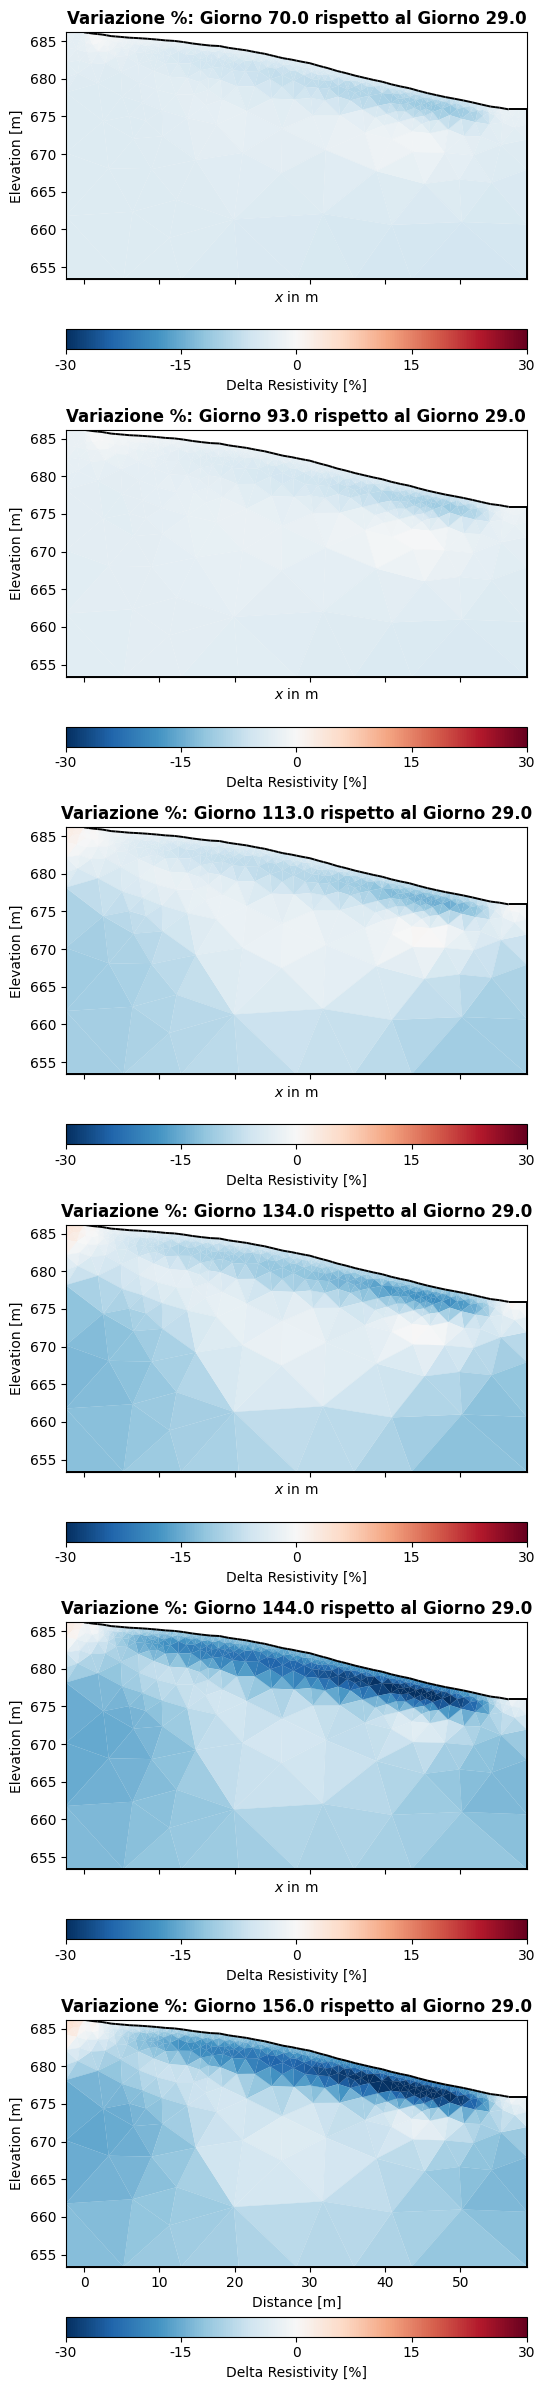

Giorno 70.0 -> Variazione Max: -0.19% | Variazione Min: -11.60%
Giorno 93.0 -> Variazione Max: -0.11% | Variazione Min: -10.84%
Giorno 113.0 -> Variazione Max: 2.11% | Variazione Min: -14.83%
Giorno 134.0 -> Variazione Max: 3.41% | Variazione Min: -18.80%
Giorno 144.0 -> Variazione Max: 2.30% | Variazione Min: -31.08%
Giorno 156.0 -> Variazione Max: 4.33% | Variazione Min: -33.23%


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 9 – Analisi Differenziale Time-Lapse (VERSIONE CORRETTA)
# Obiettivo: Mostrare dove e quanto cambia la resistività nel tempo
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
from pygimli.viewer import showMesh

print("--- FASE 9: GENERAZIONE TOMOGRAFIE DIFFERENZIALI (%) ---")

# 1. Recupero Baseline (Giorno 29)
day_base = TARGET_DAYS[0]
rho_baseline = inv_dict[day_base]
mesh_inv = mgr_dict[day_base].paraDomain # Usiamo la mesh corretta dell'inversione

# 2. Preparazione giorni da confrontare
days_to_plot = TARGET_DAYS[1:]
n_plots = len(days_to_plot)

print(f"-> Baseline: Giorno {day_base}")
print(f"-> Confronto con i giorni: {days_to_plot}")

# Creazione canvas
fig, axs = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots), sharex=True, sharey=True)
if n_plots == 1: axs = [axs]

# Scala colori: Blu = calo resistività (umido), Rosso = aumento (secco)
cMin_delta, cMax_delta = -30, 30 

# 3. Loop di calcolo Delta % e Plotting
for i, day in enumerate(days_to_plot):
    # Calcolo la variazione percentuale rispetto al Giorno 29
    rho_current = inv_dict[day]
    # FORMULA DELTA %: ((Attuale - Baseline) / Baseline) * 100
    delta_perc = ((rho_current - rho_baseline) / rho_baseline) * 100
    
    # Plot sulla mesh di inversione
    ax = axs[i]
    pg.show(mesh_inv, delta_perc, ax=ax, cmap="RdBu_r", 
            cMin=cMin_delta, cMax=cMax_delta, 
            label="Delta Resistivity [%]")
    
    ax.set_title(f"Variazione %: Giorno {day} rispetto al Giorno {day_base}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Elevation [m]")

axs[-1].set_xlabel("Distance [m]")
plt.tight_layout()
plt.show()

# 4. Statistiche di controllo
for day in days_to_plot:
    diff = ((inv_dict[day] - rho_baseline) / rho_baseline) * 100
    print(f"Giorno {day} -> Variazione Max: {np.max(diff):.2f}% | Variazione Min: {np.min(diff):.2f}%")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 10 – Visualizzazione Cinematica (I 16 Frame del Transitorio)
# Obiettivo: Analizzare l'evoluzione temporale del fronte di essiccamento
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pygimli as pg
import matplotlib.colors as mcolors

# --- IL TUO CRUSCOTTO DEL CONTRASTO ---
# Cambia questi valori per ricalibrare la scala dei colori in tutti i 16 plot
cMin_val = 5.0
cMax_val = 30.0

# Creazione dell'impalcatura visiva (Griglia 4x4)
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Ciclo di plottaggio sui 16 modelli invertiti
for i in range(len(inv_results)):
    ax = axes[i]
    
    # Disegna il tomogramma usando le tue variabili di controllo
    pg.show(mgr.paraDomain, inv_results[i], ax=ax, cMin=cMin_val, cMax=cMax_val, 
            colorBar=False, cmap='Spectral_r')
    
    # Estrai i metadati del tempo per il titolo
    kper, kstp = times[i]
    ax.set_title(f"Frame {i+1} | Periodo: {kper}, Step: {kstp}", fontsize=11, fontweight='bold')
    
    # Pulizia assi interni per leggibilità
    if i % 4 != 0:
        ax.set_ylabel("")
    if i < 12:
        ax.set_xlabel("")

# Disattivare eventuali assi vuoti se i frame fossero meno di 16 (non è il tuo caso, ma è codice robusto)
for j in range(len(inv_results), len(axes)):
    axes[j].axis('off')

# Costruzione di una colorbar unificata globale sulla destra
sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=mcolors.LogNorm(vmin=cMin_val, vmax=cMax_val))
sm._A = [] 
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Resistivita Apparente [Ohm-m]', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 11 – Analisi Dettagliata (Plot Singoli per Frame)
# Obiettivo: Esplodere l'array temporale per ispezione ad alta risoluzione
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pygimli as pg

# I controlli della dinamica visiva
cMin_val = 5.0
cMax_val = 40.0

print(f"Generazione di {len(inv_results)} plot individuali in corso...")

for i in range(len(inv_results)):
    # Creazione di una figura singola, larga e schiacciata per rispettare la topografia
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Render del tomogramma
    pg.show(mgr.paraDomain, inv_results[i], ax=ax, cMin=cMin_val, cMax=cMax_val, 
            cmap='Spectral_r', colorBar=True, label='Resistività Apparente [Ohm-m]')
    
    # Titolazione dinamica
    kper, kstp = times[i]
    ax.set_title(f"Tomografia Invertita - Frame {i+1} (Periodo: {kper}, Step: {kstp})", 
                 fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Distanza X [m]')
    ax.set_ylabel('Quota Z [m a.s.l.]')
    
    plt.tight_layout()
    plt.show()

print("Estrazione completata.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELLA 12 – Analisi Differenziale (Delta Percentuale)
# Obiettivo: Isolare il movimento dell'acqua annullando la geologia di base
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg

# Identifichiamo i fotogrammi chiave (Indici Python: 0-based)
idx_wet = 5   # Frame 6 (Fine pioggia)
idx_dry = 15  # Frame 16 (Fine drenaggio)

# Estrazione dei vettori di resistività
res_wet = np.array(inv_results[idx_wet])
res_dry = np.array(inv_results[idx_dry])

# Calcolo del Delta Resistività Percentuale
# (Dry - Wet) / Wet * 100
delta_percent = ((res_dry - res_wet) / res_wet) * 100.0

# ── Visualizzazione dell'Anomalia ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Usiamo una mappa colori divergente (Rosso = aumento resistività/essiccamento, Blu = diminuzione/bagnato)
# Fissiamo i limiti simmetrici per centrare il bianco sullo zero
limit = 50.0 # +/- 50% di variazione

pg.show(mgr.paraDomain, delta_percent, ax=ax, cmap='RdBu_r', 
        cMin=-limit, cMax=limit, label=r'Variazione di Resistività ($\Delta\rho$) [%]')

ax.set_title(f"Mappa Differenziale: Drenaggio (Giorno 16 vs Giorno 6)", fontsize=16, fontweight='bold')
ax.set_xlabel('Distanza X [m]', fontsize=12)
ax.set_ylabel('Quota Z [m a.s.l.]', fontsize=12)

plt.tight_layout()
plt.show()

# Quantificazione cruda
print("--- VERITÀ MATEMATICA DEL SEGNALE ---")
print(f"Variazione massima positiva (Essiccamento): +{np.max(delta_percent):.1f}%")
print(f"Variazione massima negativa (Saturazione anomala): {np.min(delta_percent):.1f}%")
print(f"Variazione media assoluta sul dominio: {np.mean(np.abs(delta_percent)):.1f}%")

In [ ]:
# Diagnostica della Morte Cerebrale Idrologica
h_29 = heads_dict[29.0]
h_156 = heads_dict[156.0]
differenza_massima_metri = np.max(np.abs(h_156 - h_29))
print(f"L'acqua si è mossa al massimo di: {differenza_massima_metri} metri in 4 mesi.")

In [ ]:
# ── Diagnostica di Saturazione del Modello ──
for day in [29.0, 156.0]:
    h_suc = heads_dict[day] - Z_centers
    celle_insature = np.sum(h_suc < 0)
    percentuale_insatura = (celle_insature / h_suc.size) * 100
    
    print(f"--- Giorno {day} ---")
    print(f"Celle insature (dove la geofisica può vedere l'acqua): {celle_insature} su {h_suc.size} ({percentuale_insatura:.1f}%)")
    if celle_insature > 0:
        print(f"Suzione massima raggiunta: {np.abs(np.min(h_suc)):.2f} m")
    else:
        print("ATTENZIONE: IL MODELLO È COMPLETAMENTE SOMMERSO (Saturazione 100%)")

In [ ]:
# ── AUTOPSIA DELLA RESISTIVITA' VERA ──
rho_29 = rho_true_dict[29.0]
rho_156 = rho_true_dict[156.0]

diff_assoluta = np.abs(rho_156 - rho_29)
max_diff = np.max(diff_assoluta)

print(f"DIAGNOSTICA PETROFISICA:")
print(f"-> Resistività media Giorno 29: {np.mean(rho_29):.4f} Ohm.m")
print(f"-> Resistività media Giorno 156: {np.mean(rho_156):.4f} Ohm.m")
print(f"-> VARIAZIONE MASSIMA RILEVATA: {max_diff:.8f} Ohm.m")

if max_diff == 0:
    print("\nERRORE CRITICO: La Cella 5 sta producendo matrici IDENTICHE.")
    print("Controlla se PETRO_MODE è 'LAB' e se Z_centers sta venendo sottratto correttamente.")
else:
    print(f"\nLA FISICA C'È: La variazione è di {max_diff:.4f} Ohm.m.")
    print("Se questo numero è molto piccolo (es. < 0.001), PyGIMLi lo ignora come rumore numerico.")

In [ ]:
# TEST RAPIDO DI TRASMISSIONE (Cella 7)
day_0 = TARGET_DAYS[0]
day_end = TARGET_DAYS[-1]

# 1. Controllo cosa c'è dentro il dizionario della mesh
res_mesh_0 = mesh_rho_dict[day_0]
res_mesh_end = mesh_rho_dict[day_end]
diff_mesh = np.max(np.abs(res_mesh_end - res_mesh_0))

# 2. Controllo cosa c'è dentro i dati simulati
d_0 = np.array(data_dict[day_0]['rhoa'])
d_end = np.array(data_dict[day_end]['rhoa'])
diff_apparenti = np.sum(np.abs(d_end - d_0))

print(f"DIAGNOSTICA FLUSSO DATI:")
print(f"-> Variazione sulla mesh geofisica: {diff_mesh:.4f} Ohm.m")
print(f"-> Somma differenze dati apparenti: {diff_apparenti:.4f} Ohm.m")